In [1]:
# Hotel Demand Forecasting — THEHOTEL Group
#
# Notebook structure:
#   Part 1 : Setup and data loading
#   Part 2 : EDA — four key findings
#   Part 3 : Feature engineering
#   Part 4 : Forecasting — baseline vs improved model
#   Part 5 : Evaluation and FY2021 forecast
#
# Data: hotels_sales.csv  —  11 hotels × 13 weeks × 5 years (2016–2020)
# Target: weekly revenue forecast for FY2021 Q1 (weeks 1–13)
#
# Modeling approach:
#   Train on 2016–2019 only. 2020 excluded as a shock year for most hotels.
#   Limitation acknowledged: Hotels 21 and 24 grew in 2020 (COVID-resilient)
#   — excluding 2020 for these two loses the most recent signal.

In [2]:
# Part 1: Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_PATH = Path('hotels_sales.csv')

plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

YEARS   = ['2016', '2017', '2018', '2019', '2020']
PALETTE = ['#2C5F8A', '#E07B39', '#4A9B6F', '#C94040', '#8A6BBE',
           '#D4A017', '#5B8DB8', '#A3522A', '#3D8A6B', '#8A3D5B', '#6B6B8A']

print('setup complete')

setup complete


In [3]:
# --- data loading ---
# sales columns are stored as '$1,234,567' strings — strip and convert

raw = pd.read_csv(DATA_PATH)

for yr in YEARS:
    raw[yr] = raw[yr].str.replace(r'[\$,]', '', regex=True).str.strip().astype(float)

hotels = sorted(raw['Hotel'].unique())

print(f'rows    : {len(raw)}')
print(f'hotels  : {hotels}')
print(f'weeks   : {sorted(raw["Week"].unique())}')
print()
print('Missing values')
print(raw.isnull().sum())
print()
raw.head()

rows    : 143
hotels  : [np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(59)]
weeks   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

Missing values
Week     0
Hotel    0
2016     0
2017     0
2018     0
2019     0
2020     0
dtype: int64



,Week,Hotel,2016,2017,2018,2019,2020
0,1,21,497433.0,470224.0,499591.0,475774.0,514058.0
1,1,22,507554.0,511698.0,504512.0,568714.0,573596.0
2,1,23,756729.0,743345.0,728017.0,648909.0,648779.0
3,1,24,715910.0,684969.0,618252.0,647173.0,710796.0
4,1,25,1158284.0,1153588.0,1145525.0,1285172.0,1389244.0


In [4]:
# Part 2: EDA — Four Key Findings
#
# Finding 1 : Revenue scale outliers
# Finding 2 : Hotel segmentation (growth / stable / declining)
# Finding 3 : Differential COVID impact in 2020
# Finding 4 : Seasonality and peak weeks

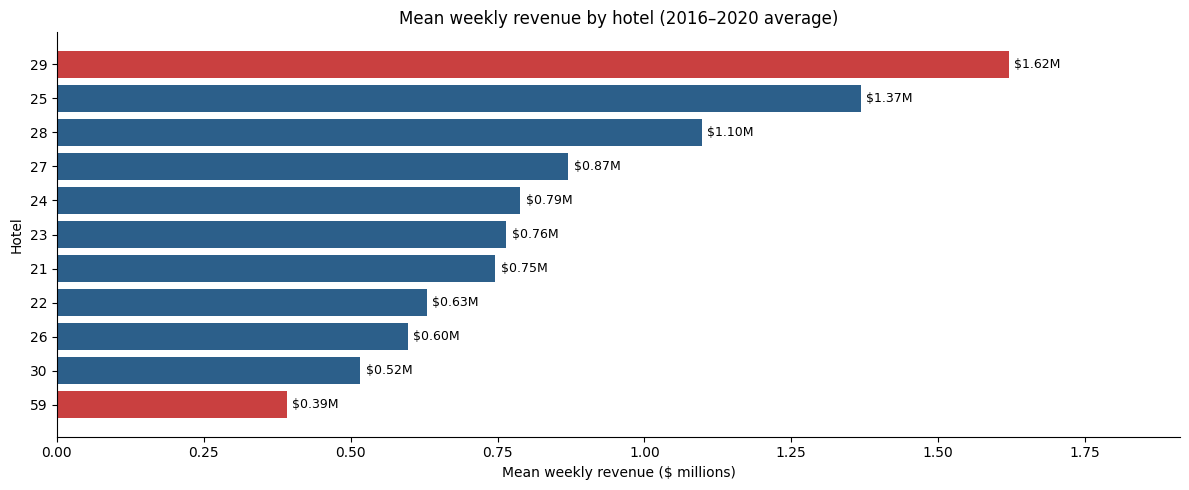

Finding 1:
  Hotel 29 is the revenue heavyweight: $1.62M / week avg
  Hotel 59 is the smallest property:  $0.39M / week avg
  Ratio Hotel 29 / Hotel 59: 4.1x


In [5]:
# --- Finding 1: Revenue scale outliers ---
# compare mean weekly revenue across all five years to spot scale differences

hotel_means = (
    raw.groupby('Hotel')[YEARS]
    .mean()
    .mean(axis=1)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots()
colors = ['#C94040' if h in [29, 59] else '#2C5F8A' for h in hotel_means.index]
bars = ax.barh(
    hotel_means.index.astype(str),
    hotel_means.values / 1e6,
    color=colors,
)
ax.bar_label(bars, fmt='$%.2fM', padding=4, fontsize=9)
ax.set_title('Mean weekly revenue by hotel (2016–2020 average)')
ax.set_xlabel('Mean weekly revenue ($ millions)')
ax.set_ylabel('Hotel')
ax.set_xlim(0, hotel_means.max() / 1e6 * 1.18)
plt.tight_layout()
plt.savefig('fig_eda_scale.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding 1:')
print(f'  Hotel 29 is the revenue heavyweight: ${hotel_means[29]/1e6:.2f}M / week avg')
print(f'  Hotel 59 is the smallest property:  ${hotel_means[59]/1e6:.2f}M / week avg')
print(f'  Ratio Hotel 29 / Hotel 59: {hotel_means[29]/hotel_means[59]:.1f}x')

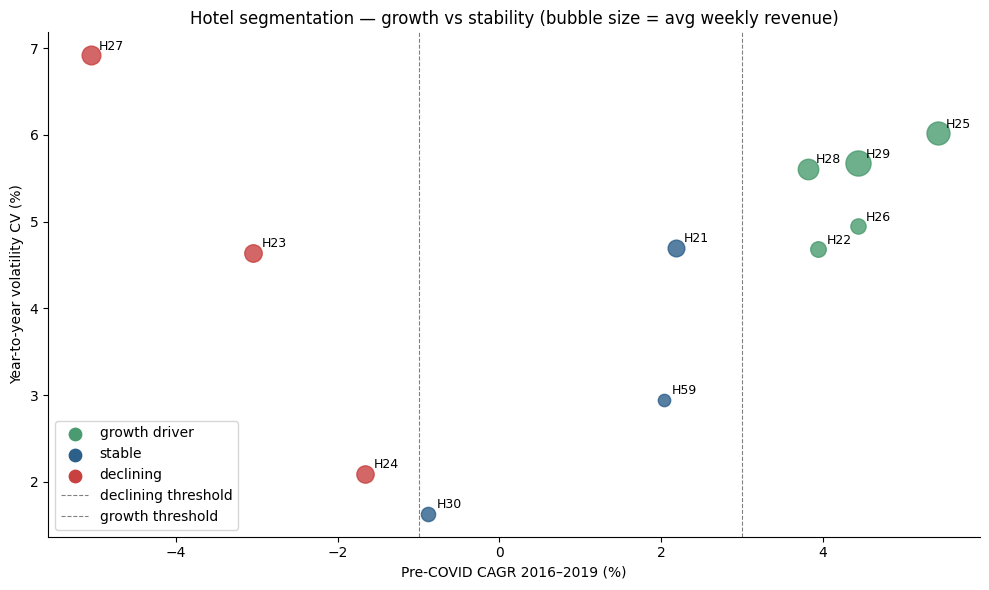

Finding 2 — segments:
   CAGR 2016-19     CV        segment
21        +2.2%  0.047         stable
22        +3.9%  0.047  growth driver
23        -3.0%  0.046      declining
24        -1.7%  0.021      declining
25        +5.4%  0.060  growth driver
26        +4.4%  0.049  growth driver
27        -5.1%  0.069      declining
28        +3.8%  0.056  growth driver
29        +4.4%  0.057  growth driver
30        -0.9%  0.016         stable
59        +2.0%  0.029         stable


In [6]:
# --- Finding 2: Hotel segmentation — growth, stable, declining ---
# CAGR 2016->2019 captures the pre-COVID trend direction
# coefficient of variation (CV) measures year-to-year stability

CLEAN_YEARS = ['2016','2017','2018','2019']

seg = pd.DataFrame(index=hotels)
for h in hotels:
    h_df = raw[raw['Hotel'] == h]
    yearly = {yr: h_df[yr].sum() for yr in CLEAN_YEARS}
    seg.loc[h, 'cagr_1619'] = (yearly['2019'] / yearly['2016']) ** (1/3) - 1
    seg.loc[h, 'cv']        = np.std(list(yearly.values())) / np.mean(list(yearly.values()))
    seg.loc[h, 'mean_weekly'] = h_df[CLEAN_YEARS].mean().mean()

# assign segments based on CAGR threshold
def assign_segment(row):
    if row['cagr_1619'] >= 0.03:
        return 'growth driver'
    elif row['cagr_1619'] <= -0.01:
        return 'declining'
    else:
        return 'stable'

seg['segment'] = seg.apply(assign_segment, axis=1)

# plot: CAGR vs CV bubble chart (bubble size = mean weekly revenue)
seg_colors = {'growth driver': '#4A9B6F', 'stable': '#2C5F8A', 'declining': '#C94040'}

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in seg.iterrows():
    ax.scatter(
        row['cagr_1619'] * 100,
        row['cv'] * 100,
        s=row['mean_weekly'] / 5000,
        color=seg_colors[row['segment']],
        alpha=0.8,
        zorder=3,
    )
    ax.annotate(
        f'H{int(_)}',
        (row['cagr_1619'] * 100, row['cv'] * 100),
        textcoords='offset points', xytext=(6, 4), fontsize=9,
    )

# legend
for label, color in seg_colors.items():
    ax.scatter([], [], color=color, label=label, s=80)
ax.axvline(-1, color='grey', linewidth=0.8, linestyle='--', label='declining threshold')
ax.axvline(3,  color='grey', linewidth=0.8, linestyle='--', label='growth threshold')
ax.set_xlabel('Pre-COVID CAGR 2016–2019 (%)')
ax.set_ylabel('Year-to-year volatility CV (%)')
ax.set_title('Hotel segmentation — growth vs stability (bubble size = avg weekly revenue)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_eda_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding 2 — segments:')
print(seg[['cagr_1619', 'cv', 'segment']]
      .rename(columns={'cagr_1619': 'CAGR 2016-19', 'cv': 'CV'})
      .assign(**{'CAGR 2016-19': lambda x: x['CAGR 2016-19'].map('{:+.1%}'.format),
                 'CV': lambda x: x['CV'].map('{:.3f}'.format)})
      .to_string())

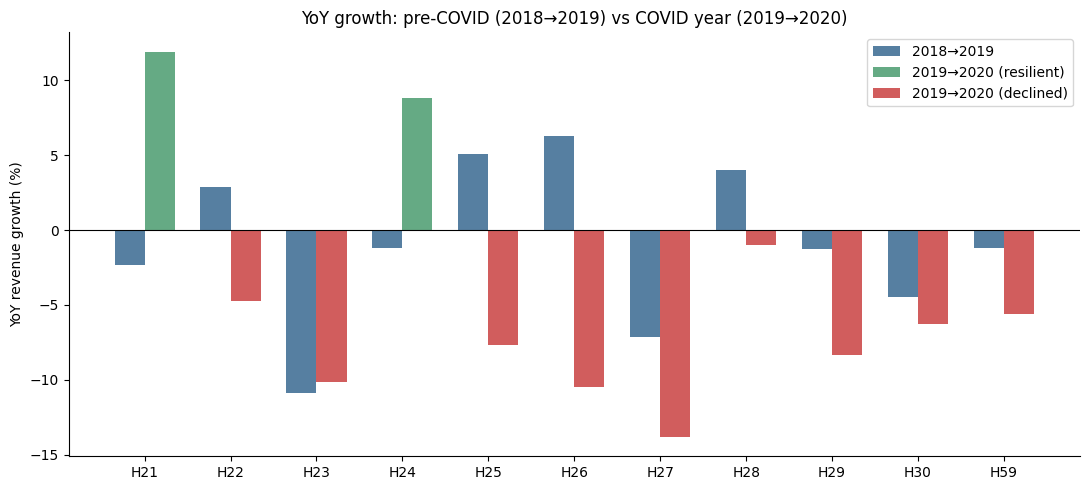

Finding 3:
  Hotels with positive 2019->2020 growth (COVID-resilient):
   YoY 2019->2020
21         +11.9%
24          +8.8%
  Hotels with largest COVID shock (yoy_1920):
   YoY 2019->2020
27         -13.8%
26         -10.5%
23         -10.1%
29          -8.4%
25          -7.7%
30          -6.2%
59          -5.6%
22          -4.7%
28          -1.0%


In [7]:
# --- Finding 3: Differential COVID impact in 2020 ---
# compare 2019->2020 YoY growth against 2018->2019 to isolate the shock

covid = pd.DataFrame(index=hotels)
for h in hotels:
    h_df = raw[raw['Hotel'] == h]
    covid.loc[h, 'yoy_1819'] = h_df['2019'].sum() / h_df['2018'].sum() - 1
    covid.loc[h, 'yoy_1920'] = h_df['2020'].sum() / h_df['2019'].sum() - 1

covid['covid_shock'] = covid['yoy_1920'] - covid['yoy_1819']
covid['resilient']  = covid['yoy_1920'] > 0

fig, ax = plt.subplots(figsize=(11, 5))
x   = range(len(hotels))
w   = 0.35
h_labels = [f'H{h}' for h in hotels]

bars_pre = ax.bar([i - w/2 for i in x], covid['yoy_1819'] * 100,
                  width=w, label='2018→2019', color='#2C5F8A', alpha=0.8)
bars_cov = ax.bar([i + w/2 for i in x], covid['yoy_1920'] * 100,
                  width=w, label='2019→2020',
                  color=['#4A9B6F' if v else '#C94040'
                         for v in covid['resilient']], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(h_labels)
ax.set_ylabel('YoY revenue growth (%)')
ax.set_title('YoY growth: pre-COVID (2018→2019) vs COVID year (2019→2020)')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2C5F8A', alpha=0.8, label='2018→2019'),
    Patch(facecolor='#4A9B6F', alpha=0.85, label='2019→2020 (resilient)'),
    Patch(facecolor='#C94040', alpha=0.85, label='2019→2020 (declined)'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('fig_eda_covid.png', dpi=150, bbox_inches='tight')
plt.show()

print('Finding 3:')
print('  Hotels with positive 2019->2020 growth (COVID-resilient):')
print(covid[covid['resilient']][['yoy_1920']]
      .rename(columns={'yoy_1920': 'YoY 2019->2020'})
      .map('{:+.1%}'.format).to_string())
print('  Hotels with largest COVID shock (yoy_1920):')
print(covid[~covid['resilient']][['yoy_1920']]
      .sort_values('yoy_1920')
      .rename(columns={'yoy_1920': 'YoY 2019->2020'})
      .map('{:+.1%}'.format).to_string())

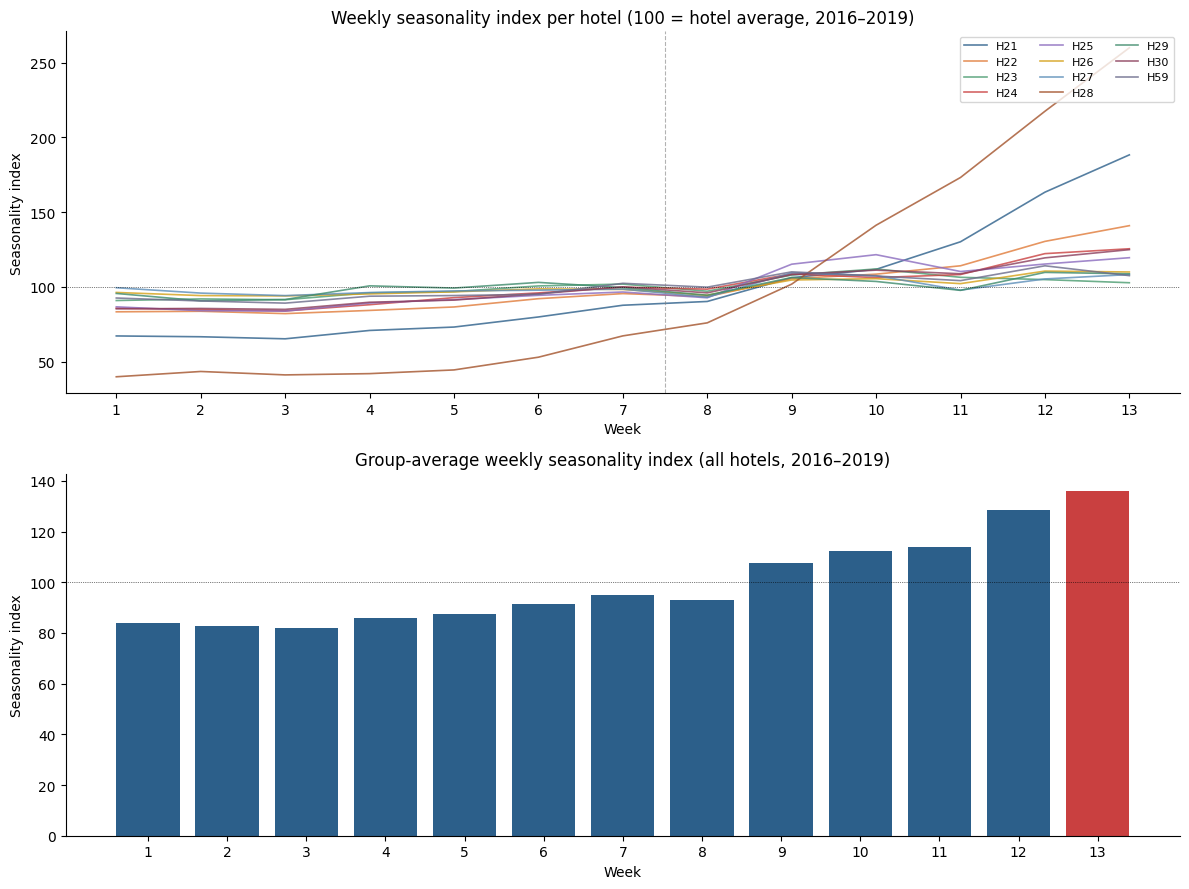

Finding 4:
  Group-level peak week: 13 (index = 136.0)
  Lowest week: 3 (index = 81.9)

  Per-hotel peak weeks (2016-2019):
    Hotel 21: peak week 13 ($1,362,352)
    Hotel 22: peak week 13 ($885,193)
    Hotel 23: peak week 10 ($886,404)
    Hotel 24: peak week 13 ($975,543)
    Hotel 25: peak week 10 ($1,663,130)
    Hotel 26: peak week 12 ($665,014)
    Hotel 27: peak week 9 ($995,612)
    Hotel 28: peak week 13 ($2,817,027)
    Hotel 29: peak week 12 ($1,791,406)
    Hotel 30: peak week 13 ($656,242)
    Hotel 59: peak week 12 ($450,420)


In [8]:
# --- Finding 4: Seasonality and peak weeks ---
# use 2016–2019 only (clean years) to identify week-of-year patterns
# normalise each hotel to its own mean to compare shape not scale

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# panel 1: normalised weekly index per hotel
ax1 = axes[0]
for i, h in enumerate(hotels):
    h_df = raw[raw['Hotel'] == h].sort_values('Week')
    weekly_avg = h_df.groupby('Week')[CLEAN_YEARS].mean().mean(axis=1)
    index = weekly_avg / weekly_avg.mean() * 100
    ax1.plot(index.index, index.values,
             color=PALETTE[i], linewidth=1.2, alpha=0.8, label=f'H{h}')

ax1.axvline(7.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax1.axhline(100, color='black', linewidth=0.5, linestyle=':')
ax1.set_title('Weekly seasonality index per hotel (100 = hotel average, 2016–2019)')
ax1.set_xlabel('Week')
ax1.set_ylabel('Seasonality index')
ax1.set_xticks(range(1, 14))
ax1.legend(loc='upper right', fontsize=8, ncol=3)

# panel 2: group-level average weekly index
ax2 = axes[1]
all_indices = []
for h in hotels:
    h_df = raw[raw['Hotel'] == h].sort_values('Week')
    weekly_avg = h_df.groupby('Week')[CLEAN_YEARS].mean().mean(axis=1)
    index = weekly_avg / weekly_avg.mean() * 100
    all_indices.append(index)

group_index = pd.concat(all_indices, axis=1).mean(axis=1)
bar_colors  = ['#C94040' if group_index[w] == group_index.max()
               else '#2C5F8A' for w in group_index.index]
ax2.bar(group_index.index, group_index.values, color=bar_colors)
ax2.axhline(100, color='black', linewidth=0.5, linestyle=':')
ax2.set_title('Group-average weekly seasonality index (all hotels, 2016–2019)')
ax2.set_xlabel('Week')
ax2.set_ylabel('Seasonality index')
ax2.set_xticks(range(1, 14))

plt.tight_layout()
plt.savefig('fig_eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

peak_week = group_index.idxmax()
print(f'Finding 4:')
print(f'  Group-level peak week: {peak_week} (index = {group_index[peak_week]:.1f})')
print(f'  Lowest week: {group_index.idxmin()} (index = {group_index.min():.1f})')
print()
print('  Per-hotel peak weeks (2016-2019):')
for h in hotels:
    h_df = raw[raw['Hotel'] == h].sort_values('Week')
    weekly_avg = h_df.groupby('Week')[CLEAN_YEARS].mean().mean(axis=1)
    print(f'    Hotel {h}: peak week {weekly_avg.idxmax()} (${weekly_avg.max():,.0f})')

In [9]:
# --- EDA summary table ---

summary = seg.copy()
for h in hotels:
    summary.loc[h, 'yoy_1920'] = covid.loc[h, 'yoy_1920']

summary = summary[['mean_weekly', 'cagr_1619', 'cv', 'yoy_1920', 'segment']]
summary.index.name = 'Hotel'
summary.columns = ['Mean weekly ($)', 'CAGR 2016-19', 'Volatility CV', 'YoY 2019-20', 'Segment']

print('EDA summary')
print(
    summary
    .assign(**{
        'Mean weekly ($)': lambda x: x['Mean weekly ($)'].map('${:,.0f}'.format),
        'CAGR 2016-19'   : lambda x: x['CAGR 2016-19'].map('{:+.1%}'.format),
        'Volatility CV'  : lambda x: x['Volatility CV'].map('{:.3f}'.format),
        'YoY 2019-20'    : lambda x: x['YoY 2019-20'].map('{:+.1%}'.format),
    })
    .to_string()
)

EDA summary
      Mean weekly ($) CAGR 2016-19 Volatility CV YoY 2019-20        Segment
Hotel                                                                      
21           $723,626        +2.2%         0.047      +11.9%         stable
22           $628,193        +3.9%         0.047       -4.7%  growth driver
23           $791,899        -3.0%         0.046      -10.1%      declining
24           $777,588        -1.7%         0.021       +8.8%      declining
25         $1,368,891        +5.4%         0.060       -7.7%  growth driver
26           $601,725        +4.4%         0.049      -10.5%  growth driver
27           $910,589        -5.1%         0.069      -13.8%      declining
28         $1,083,840        +3.8%         0.056       -1.0%  growth driver
29         $1,633,663        +4.4%         0.057       -8.4%  growth driver
30           $525,551        -0.9%         0.016       -6.2%         stable
59           $394,895        +2.0%         0.029       -5.6%         stable


In [10]:
# Part 3: Feature Engineering
#
# Approach: one global model using all hotels and years.
# With only 52 observations per hotel (4 years × 13 weeks),
# a per-hotel model is too data-limited beyond a simple average.
# A global model with hotel identity and segment as features
# uses all 572 rows and captures cross-hotel patterns.
#
# Training data: 2016–2019 only (2020 excluded as a shock year).
# Validation : hold out 2019, train on 2016–2018.
# Forecast   : retrain on 2016–2019, predict 2021.

In [11]:
# --- 3.1  reshape to long format ---
# rename Week->week early — before all feature computation
# to ensure consistent column name throughout

long = raw.melt(
    id_vars=['Week', 'Hotel'],
    value_vars=YEARS,
    var_name='year',
    value_name='sales',
)
long['year'] = long['year'].astype(int)
long = long.rename(columns={'Week': 'week'})
long = long.sort_values(['Hotel', 'year', 'week']).reset_index(drop=True)

print('long format shape:', long.shape)
long.head(8)

long format shape: (715, 4)


,week,Hotel,year,sales
0,1,21,2016,497433.0
1,2,21,2016,471576.0
2,3,21,2016,443125.0
3,4,21,2016,493939.0
4,5,21,2016,482563.0
5,6,21,2016,564957.0
6,7,21,2016,626379.0
7,8,21,2016,582190.0


In [12]:
# --- 3.2  hotel-level metadata from EDA ---
# segment and volatility (CV) computed in Part 2 are joined here

SEGMENT_MAP = {'declining': 0, 'stable': 1, 'growth driver': 2}

hotel_meta = seg[['cv', 'segment', 'hotel_avg' if 'hotel_avg' in seg.columns else 'mean_weekly']].copy()
hotel_meta = hotel_meta.rename(columns={'mean_weekly': 'hotel_avg'})
hotel_meta['segment_encoded'] = hotel_meta['segment'].map(SEGMENT_MAP)
hotel_meta['hotel_cv']        = hotel_meta['cv']

long = long.merge(
    hotel_meta[['hotel_avg', 'segment_encoded', 'hotel_cv']],
    left_on='Hotel', right_index=True, how='left',
)

print('segment encoding:', SEGMENT_MAP)
print(hotel_meta[['segment', 'segment_encoded', 'hotel_cv']].to_string())

segment encoding: {'declining': 0, 'stable': 1, 'growth driver': 2}
          segment  segment_encoded  hotel_cv
21         stable                1  0.046988
22  growth driver                2  0.046825
23      declining                0  0.046414
24      declining                0  0.020916
25  growth driver                2  0.060184
26  growth driver                2  0.049448
27      declining                0  0.069183
28  growth driver                2  0.056085
29  growth driver                2  0.056750
30         stable                1  0.016313
59         stable                1  0.029467


In [13]:
# --- 3.3  time-based features ---
# all lookback features are computed strictly from prior years
# to avoid any data leakage into the validation or forecast sets

long = long.sort_values(['Hotel', 'week', 'year']).reset_index(drop=True)

# prev_year_sales: sales from year-1 for the same hotel-week
long['prev_year_sales'] = (
    long.groupby(['Hotel', 'week'])['sales']
    .shift(1)
)

# rolling_mean_2yr: mean of last 2 years for same hotel-week
long['prev2_year_sales'] = (
    long.groupby(['Hotel', 'week'])['sales']
    .shift(2)
)

# rolling_mean_2yr: average of last 2 years for same hotel-week
long['rolling_mean_2yr'] = (
    (long['prev_year_sales'] + long['prev2_year_sales']) / 2
)

# hist_avg: cumulative mean of all prior years for same hotel-week
long['hist_avg'] = (
    long.groupby(['Hotel', 'week'])['sales']
    .apply(lambda s: s.shift(1).expanding().mean())
    .values
)

# yoy_growth: (year-1 / year-2) - 1 — momentum signal
long['yoy_growth'] = (
    long['prev_year_sales'] / long['prev2_year_sales'] - 1
).clip(-0.5, 0.5)  # cap extreme values

# week_seasonality_idx: hotel's weekly avg / hotel overall avg (from 2016-2019)
clean = long[long['year'].isin([2016, 2017, 2018, 2019])]
week_idx = (
    clean.groupby(['Hotel', 'week'])['sales'].mean()
    / clean.groupby('Hotel')['sales'].mean()
).rename('week_seasonality_idx').reset_index()

long = long.merge(week_idx, on=['Hotel', 'week'], how='left')

print('features added:', ['prev_year_sales', 'rolling_mean_2yr', 'hist_avg',
                           'yoy_growth', 'week_seasonality_idx'])
print('rows with NaN (first year has no lookback):')
print(long[long['year'] == 2016][['prev_year_sales']].isna().sum().to_string())

features added: ['prev_year_sales', 'rolling_mean_2yr', 'hist_avg', 'yoy_growth', 'week_seasonality_idx']
rows with NaN (first year has no lookback):
prev_year_sales    143


In [14]:
# --- 3.4  build train, validation, and forecast datasets ---
# note: after dropna, 2017 rows are removed because prev2_year_sales
# requires two years of lookback and 2017 only has one (2016).
# effective split: train year = 2018, validation year = 2019.

FEATURES = [
    'Hotel',                 # hotel identity
    'week',                  # week of year
    'prev_year_sales',       # most recent signal
    'rolling_mean_2yr',      # short-term average
    'hist_avg',              # long-run average
    'yoy_growth',            # momentum
    'week_seasonality_idx',  # within-hotel seasonality shape
    'hotel_avg',             # hotel scale
    'segment_encoded',       # growth / stable / declining
    'hotel_cv',              # volatility
]
TARGET = 'sales'

modelling     = long[long['year'] >= 2017].copy()
df_train      = modelling[modelling['year'].isin([2017, 2018])].dropna(subset=FEATURES)
df_val        = modelling[modelling['year'] == 2019].dropna(subset=FEATURES)
df_train_full = modelling[modelling['year'].isin([2017, 2018, 2019])].dropna(subset=FEATURES)

X_train      = df_train[FEATURES];      y_train      = df_train[TARGET]
X_val        = df_val[FEATURES];        y_val        = df_val[TARGET]
X_train_full = df_train_full[FEATURES]; y_train_full = df_train_full[TARGET]

print('train year distribution:')
print(df_train['year'].value_counts().sort_index().to_string())
print('\nval year distribution:')
print(df_val['year'].value_counts().sort_index().to_string())
print('\nfull train year distribution:')
print(df_train_full['year'].value_counts().sort_index().to_string())

train year distribution:
year
2018    143

val year distribution:
year
2019    143

full train year distribution:
year
2018    143
2019    143


In [15]:
# --- 3.5  prepare 2021 forecast input ---
# 2021 has no observed sales.
# 2020 is excluded as a shock year — 2019 is used as prev_year_sales.
# rolling_mean_2yr = mean(2018, 2019); hist_avg = mean(2016–2019).
# limitation: this assumes 2021 demand recovers toward the 2019 level,
# which may underestimate resilient hotels (21, 24) if recovery exceeds trend.

forecast_rows = []
for h in hotels:
    for w in range(1, 14):
        h_hist = long[(long['Hotel'] == h) & (long['week'] == w)].sort_values('year')
        clean_hist = h_hist[h_hist['year'].isin([2016, 2017, 2018, 2019])]

        prev_yr   = clean_hist[clean_hist['year'] == 2019]['sales'].values[0]
        prev2_yr  = clean_hist[clean_hist['year'] == 2018]['sales'].values[0]
        hist_mean = clean_hist['sales'].mean()
        roll2     = clean_hist[clean_hist['year'].isin([2018, 2019])]['sales'].mean()
        yoy       = np.clip(prev_yr / prev2_yr - 1, -0.5, 0.5)
        wk_idx    = week_idx[(week_idx['Hotel'] == h) &
                             (week_idx['week'] == w)]['week_seasonality_idx'].values[0]

        forecast_rows.append({
            'Hotel'               : h,
            'week'                : w,
            'prev_year_sales'     : prev_yr,
            'rolling_mean_2yr'    : roll2,
            'hist_avg'            : hist_mean,
            'yoy_growth'          : yoy,
            'week_seasonality_idx': wk_idx,
            'hotel_avg'           : hotel_meta.loc[h, 'hotel_avg'],
            'segment_encoded'     : hotel_meta.loc[h, 'segment_encoded'],
            'hotel_cv'            : hotel_meta.loc[h, 'hotel_cv'],
        })

df_forecast = pd.DataFrame(forecast_rows)
X_forecast  = df_forecast[FEATURES]

print('forecast rows:', len(df_forecast))
df_forecast.head(4)

forecast rows: 143


,Hotel,week,prev_year_sales,rolling_mean_2yr,hist_avg,yoy_growth,week_seasonality_idx,hotel_avg,segment_encoded,hotel_cv
0,21,1,475774.0,487682.5,485755.50,-0.047673,0.671279,723626.346154,1,0.046988
1,21,2,465924.0,505539.5,481831.00,-0.145337,0.665856,723626.346154,1,0.046988
2,21,3,450653.0,473351.5,471890.75,-0.091517,0.652119,723626.346154,1,0.046988
3,21,4,477398.0,527071.0,512368.25,-0.172253,0.708056,723626.346154,1,0.046988


In [17]:
# Part 4: Forecasting — Baseline vs Ridge Regression
#
# Baseline : hotel × week historical mean
# Improved  : Ridge regression with 5-fold CV for alpha selection
#
# CV note: LOOCV was considered but 5-fold is chosen as a pragmatic
# compromise. LOOCV on 143 rows produces highly correlated folds,
# inflating the variance of the alpha estimate. 5-fold trains on
# ~114 observations per fold — close to LOOCV coverage with lower variance.
# Alpha selection is for tuning only; 2019 hold-out is the honest evaluation.
#
# Hotel ID is excluded from features. hotel_avg, segment_encoded, and
# hotel_cv serve as hotel-level proxies (implicit target encoding).
# Limitation: hotel-specific intercepts not captured beyond these three features.

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

FEATURES_MODEL = [f for f in FEATURES if f != 'Hotel']
print('features used in model:', FEATURES_MODEL)

features used in model: ['week', 'prev_year_sales', 'rolling_mean_2yr', 'hist_avg', 'yoy_growth', 'week_seasonality_idx', 'hotel_avg', 'segment_encoded', 'hotel_cv']


In [22]:
# --- 4.1  baseline: hotel × week historical mean ---
# predict the mean of all training years for each hotel-week pair
# computed directly from df_train — no features, no learning

baseline_lookup = (
    df_train.groupby(['Hotel', 'week'])['sales']
    .mean()
    .rename('baseline_pred')
    .reset_index()
)

# validation predictions (2019)
val_baseline = df_val.merge(baseline_lookup, on=['Hotel', 'week'], how='left')

# forecast predictions (2021) — same lookup, no 2021 actuals exist
forecast_baseline = df_forecast.merge(baseline_lookup, on=['Hotel', 'week'], how='left')

mae_baseline = mean_absolute_error(val_baseline['sales'], val_baseline['baseline_pred'])
mape_baseline = ((
    (val_baseline['sales'] - val_baseline['baseline_pred']).abs()
    / val_baseline['sales']
).mean() * 100)

print(f'baseline — overall MAE  : ${mae_baseline:,.0f}')
print(f'baseline — overall MAPE : {mape_baseline:.1f}%')

baseline — overall MAE  : $77,809
baseline — overall MAPE : 8.7%


In [23]:
# --- 4.2  feature scaling ---
# fit scaler on training set only — never on validation or forecast

scaler = StandardScaler()
X_train_s      = scaler.fit_transform(df_train[FEATURES_MODEL])
X_val_s        = scaler.transform(df_val[FEATURES_MODEL])
X_train_full_s = scaler.transform(df_train_full[FEATURES_MODEL])
X_forecast_s   = scaler.transform(df_forecast[FEATURES_MODEL])

print('scaler fit on training set only')
print(f'  train shape    : {X_train_s.shape}')
print(f'  val shape      : {X_val_s.shape}')
print(f'  full train shape: {X_train_full_s.shape}')
print(f'  forecast shape : {X_forecast_s.shape}')

scaler fit on training set only
  train shape    : (143, 9)
  val shape      : (143, 9)
  full train shape: (286, 9)
  forecast shape : (143, 9)


In [24]:
# --- 4.3  alpha selection via 5-fold CV ---

alphas = np.logspace(-2, 5, 100)  # 0.01 to 100,000

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5,
    scoring='neg_mean_absolute_error',
)
ridge_cv.fit(X_train_s, y_train)

best_alpha = ridge_cv.alpha_
print(f'best alpha (5-fold CV): {best_alpha:.2f}')

best alpha (5-fold CV): 4.86


In [25]:
# --- 4.4  train Ridge on 2018 and evaluate on 2019 ---

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_s, y_train)

val_pred_ridge = ridge.predict(X_val_s)

mae_ridge = mean_absolute_error(y_val, val_pred_ridge)
mape_ridge = ((
    pd.Series(y_val.values - val_pred_ridge).abs()
    / pd.Series(y_val.values)
).mean() * 100)

print(f'Ridge — overall MAE  : ${mae_ridge:,.0f}')
print(f'Ridge — overall MAPE : {mape_ridge:.1f}%')
print()
print(f'improvement over baseline — MAE  : ${mae_baseline - mae_ridge:,.0f}')
print(f'improvement over baseline — MAPE : {mape_baseline - mape_ridge:.1f} pp')

Ridge — overall MAE  : $65,372
Ridge — overall MAPE : 7.3%

improvement over baseline — MAE  : $12,437
improvement over baseline — MAPE : 1.4 pp


In [26]:
# --- 4.5  per-hotel evaluation on 2019 ---
# calculate hotel-level errors, not only global metrics

df_val_eval = df_val.copy().reset_index(drop=True)
df_val_eval['ridge_pred']    = val_pred_ridge
df_val_eval['baseline_pred'] = val_baseline['baseline_pred'].values

per_hotel = []
for h in hotels:
    hv = df_val_eval[df_val_eval['Hotel'] == h]
    mae_b  = mean_absolute_error(hv['sales'], hv['baseline_pred'])
    mape_b = ((hv['sales'] - hv['baseline_pred']).abs() / hv['sales']).mean() * 100
    mae_r  = mean_absolute_error(hv['sales'], hv['ridge_pred'])
    mape_r = ((hv['sales'] - hv['ridge_pred']).abs() / hv['sales']).mean() * 100
    per_hotel.append({
        'Hotel'          : h,
        'Segment'        : hotel_meta.loc[h, 'segment'],
        'Baseline MAE'   : mae_b,
        'Ridge MAE'      : mae_r,
        'Baseline MAPE %': mape_b,
        'Ridge MAPE %'   : mape_r,
    })

hotel_eval = pd.DataFrame(per_hotel).set_index('Hotel')
print('per-hotel evaluation on 2019 hold-out')
print(hotel_eval.round(1).to_string())

per-hotel evaluation on 2019 hold-out
             Segment  Baseline MAE  Ridge MAE  Baseline MAPE %  Ridge MAPE %
Hotel                                                                       
21            stable       78091.5    72910.0             11.0           8.8
22     growth driver       47766.5    41375.5              6.9           5.6
23         declining       94138.9    66166.2             13.1           9.3
24         declining       45666.9    31468.5              6.1           4.0
25     growth driver      101466.1    53811.5              6.7           3.6
26     growth driver       44230.6    22637.9              6.7           3.5
27         declining       82161.1    81939.4             10.1          10.0
28     growth driver      231481.2   199275.7             17.8          17.0
29     growth driver       70849.2    82942.1              4.2           5.0
30            stable       37491.8    47377.5              7.5           8.8
59            stable       22551.5    

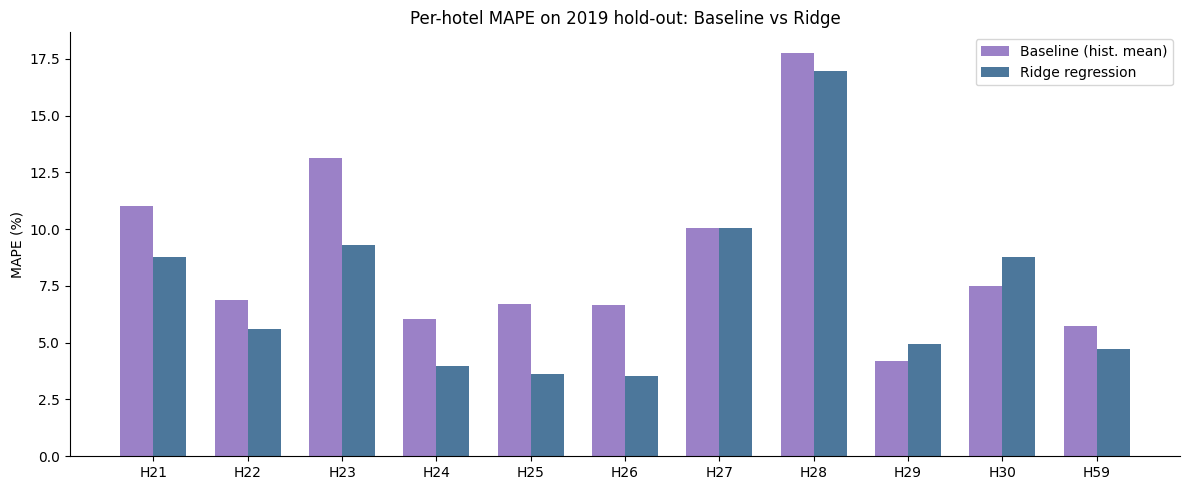

In [27]:
# --- 4.6  comparison chart: per-hotel MAPE baseline vs Ridge ---

x      = np.arange(len(hotels))
w      = 0.35
labels = [f'H{h}' for h in hotels]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, hotel_eval['Baseline MAPE %'], width=w,
       label='Baseline (hist. mean)', color='#8A6BBE', alpha=0.85)
ax.bar(x + w/2, hotel_eval['Ridge MAPE %'],    width=w,
       label='Ridge regression',      color='#2C5F8A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('MAPE (%)')
ax.set_title('Per-hotel MAPE on 2019 hold-out: Baseline vs Ridge')
ax.legend()
plt.tight_layout()
plt.savefig('fig_eval_mape.png', dpi=150, bbox_inches='tight')
plt.show()

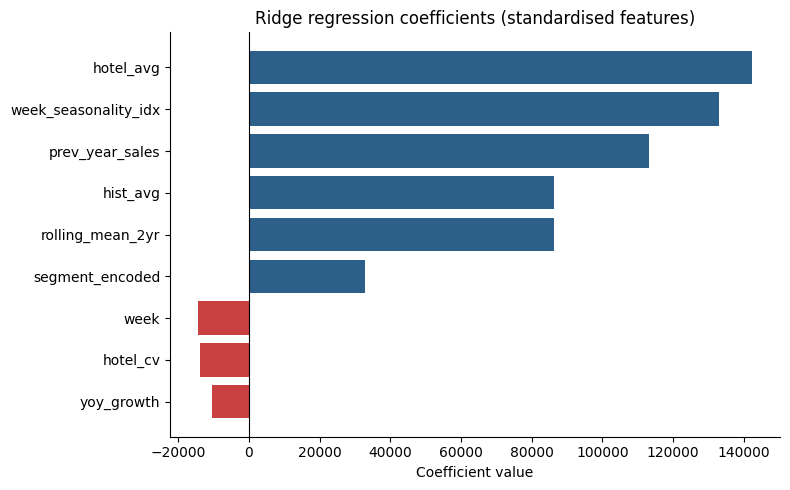

             feature   coefficient
          yoy_growth -10532.887242
            hotel_cv -13767.540867
                week -14500.289807
     segment_encoded  32948.285868
    rolling_mean_2yr  86251.173142
            hist_avg  86251.173142
     prev_year_sales 113244.823653
week_seasonality_idx 133129.737447
           hotel_avg 142427.529409


In [40]:
# --- 4.7  feature coefficients ---
# Ridge coefficients show which features carry the most weight

coef_df = pd.DataFrame({
    'feature'    : FEATURES_MODEL,
    'coefficient': ridge.coef_,
}).reindex(pd.Series(ridge.coef_).abs().sort_values(ascending=False).index)

coef_df = pd.DataFrame({
    'feature'    : FEATURES_MODEL,
    'coefficient': ridge.coef_,
}).assign(abs_coef=lambda x: x['coefficient'].abs())\
  .sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['feature'], coef_df['coefficient'],
        color=['#C94040' if c < 0 else '#2C5F8A' for c in coef_df['coefficient']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge regression coefficients (standardised features)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('fig_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df[['feature', 'coefficient']].to_string(index=False))

In [41]:
# --- 4.8  retrain on 2018+2019 and produce 2021 forecast ---
# refit scaler on full training data before final forecast

scaler_full = StandardScaler()
X_train_full_s2 = scaler_full.fit_transform(df_train_full[FEATURES_MODEL])
X_forecast_s2   = scaler_full.transform(df_forecast[FEATURES_MODEL])

ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train_full_s2, y_train_full)

df_forecast['ridge_2021']    = ridge_final.predict(X_forecast_s2)
df_forecast['baseline_2021'] = forecast_baseline['baseline_pred'].values

print('FY2021 Q1 forecast — first 15 rows')
print(df_forecast[['Hotel', 'week', 'baseline_2021', 'ridge_2021']]
      .assign(baseline_2021=lambda x: x['baseline_2021'].map('${:,.0f}'.format),
              ridge_2021   =lambda x: x['ridge_2021'].map('${:,.0f}'.format))
      .head(15).to_string(index=False))

FY2021 Q1 forecast — first 15 rows
 Hotel  week baseline_2021 ridge_2021
    21     1      $499,591   $447,207
    21     2      $545,155   $451,977
    21     3      $496,050   $431,100
    21     4      $576,744   $487,077
    21     5      $602,415   $508,855
    21     6      $648,306   $567,298
    21     7      $702,337   $637,619
    21     8      $676,337   $653,095
    21     9      $772,065   $790,986
    21    10      $775,800   $835,314
    21    11      $899,987   $992,888
    21    12    $1,188,092 $1,294,696
    21    13    $1,565,507 $1,538,693
    22     1      $504,512   $542,578
    22     2      $551,910   $554,208


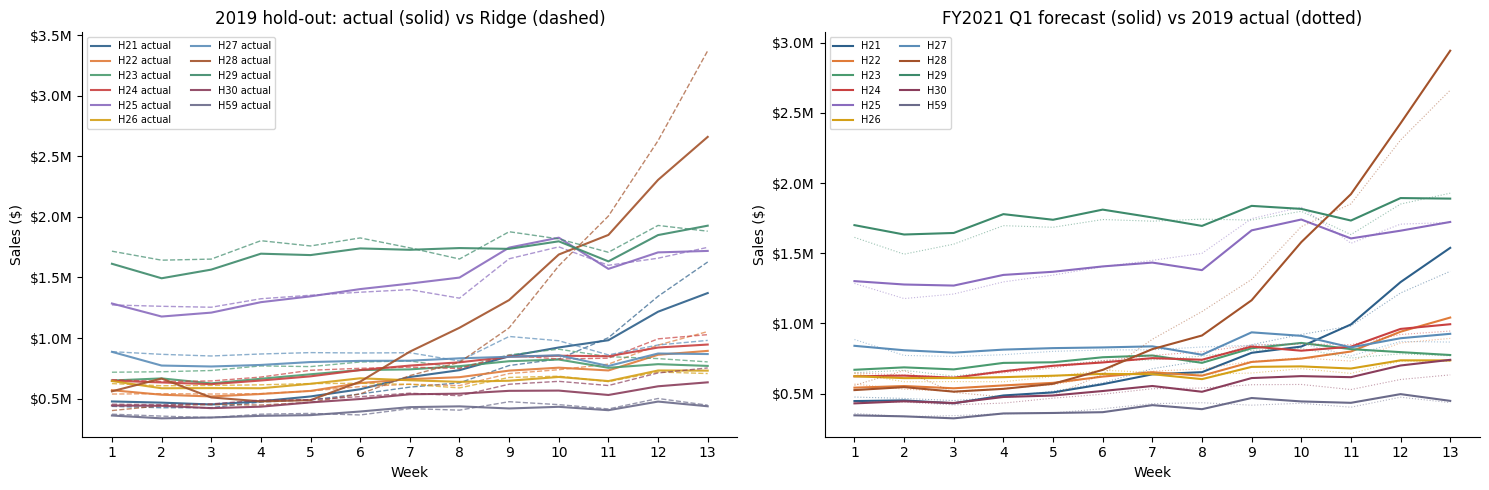

In [42]:
# --- 4.9  forecast visualisation ---
# two panels: validation fit (2019 actual vs predicted) and 2021 forecast

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# panel 1: actual vs Ridge prediction on 2019 hold-out
ax1 = axes[0]
for i, h in enumerate(hotels):
    hv = df_val_eval[df_val_eval['Hotel'] == h].sort_values('week')
    ax1.plot(hv['week'], hv['sales'],       color=PALETTE[i],
             linewidth=1.5, alpha=0.9, label=f'H{h} actual')
    ax1.plot(hv['week'], hv['ridge_pred'],  color=PALETTE[i],
             linewidth=1, linestyle='--', alpha=0.7)
ax1.set_title('2019 hold-out: actual (solid) vs Ridge (dashed)')
ax1.set_xlabel('Week')
ax1.set_ylabel('Sales ($)')
ax1.set_xticks(range(1, 14))
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
ax1.legend(fontsize=7, ncol=2)

# panel 2: 2021 Ridge forecast vs 2019 actual as reference
ax2 = axes[1]
for i, h in enumerate(hotels):
    hf = df_forecast[df_forecast['Hotel'] == h].sort_values('week')
    hv = df_val_eval[df_val_eval['Hotel'] == h].sort_values('week')
    ax2.plot(hf['week'], hf['ridge_2021'], color=PALETTE[i],
             linewidth=1.5, label=f'H{h}')
    ax2.plot(hv['week'], hv['sales'],      color=PALETTE[i],
             linewidth=0.8, linestyle=':', alpha=0.5)
ax2.set_title('FY2021 Q1 forecast (solid) vs 2019 actual (dotted)')
ax2.set_xlabel('Week')
ax2.set_ylabel('Sales ($)')
ax2.set_xticks(range(1, 14))
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('fig_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Part 5: Evaluation and FY2021 Forecast Interpretation
#
# Structure:
#   5.1  evaluation summary table
#   5.2  segmented evaluation narrative
#   5.3  model selection table (two-gate logic)
#   5.4  business interpretation
#   5.5  FY2021 Q1 summary table

In [48]:
# --- 5.1  evaluation summary table ---

eval_summary = hotel_eval.copy()
eval_summary['MAPE delta (pp)'] = (
    eval_summary['Baseline MAPE %'] - eval_summary['Ridge MAPE %']
)
eval_summary['Ridge vs Baseline'] = eval_summary['MAPE delta (pp)'].apply(
    lambda d: 'better' if d >= 0.5 else ('worse' if d < -0.5 else 'indifferent')
)

print('Evaluation summary — 2019 hold-out')
print(eval_summary[['Segment', 'Baseline MAPE %', 'Ridge MAPE %',
                     'MAPE delta (pp)', 'Ridge vs Baseline']]
      .round(1).to_string())
print(f'\nGlobal — Baseline MAPE: {mape_b:.1f}%  |  Ridge MAPE: {mape_r:.1f}%')
print(f'Overall improvement: {mape_b - mape_r:.1f} pp')

Evaluation summary — 2019 hold-out
             Segment  Baseline MAPE %  Ridge MAPE %  MAPE delta (pp) Ridge vs Baseline
Hotel                                                                                 
21            stable             11.0           8.8              2.2            better
22     growth driver              6.9           5.6              1.3            better
23         declining             13.1           9.3              3.9            better
24         declining              6.1           4.0              2.1            better
25     growth driver              6.7           3.6              3.1            better
26     growth driver              6.7           3.5              3.1            better
27         declining             10.1          10.0              0.0       indifferent
28     growth driver             17.8          17.0              0.8            better
29     growth driver              4.2           5.0             -0.8             worse
30      

In [51]:
# --- 5.2  segmented evaluation narrative ---

for seg_name in ['growth driver', 'stable', 'declining']:
    seg_hotels = [h for h in hotels if hotel_meta.loc[h, 'segment'] == seg_name]
    seg_df = eval_summary.loc[seg_hotels]
    avg_baseline = seg_df['Baseline MAPE %'].mean()
    avg_ridge    = seg_df['Ridge MAPE %'].mean()
    print(f'Segment: {seg_name}')
    print(f'  Hotels : {seg_hotels}')
    print(f'  Avg baseline MAPE : {avg_baseline:.1f}%')
    print(f'  Avg Ridge MAPE    : {avg_ridge:.1f}%')
    for h in seg_hotels:
        flag = eval_summary.loc[h, 'Ridge vs Baseline']
        print(f'  H{h}: {flag}')
    print()

Segment: growth driver
  Hotels : [np.int64(22), np.int64(25), np.int64(26), np.int64(28), np.int64(29)]
  Avg baseline MAPE : 8.4%
  Avg Ridge MAPE    : 6.9%
  H22: better
  H25: better
  H26: better
  H28: better
  H29: worse

Segment: stable
  Hotels : [np.int64(21), np.int64(30), np.int64(59)]
  Avg baseline MAPE : 8.1%
  Avg Ridge MAPE    : 7.4%
  H21: better
  H30: worse
  H59: better

Segment: declining
  Hotels : [np.int64(23), np.int64(24), np.int64(27)]
  Avg baseline MAPE : 9.7%
  Avg Ridge MAPE    : 7.8%
  H23: better
  H24: better
  H27: indifferent



In [52]:
# --- 5.3  model selection — two-gate logic ---
# gate 1: does Ridge beat baseline (delta > 0.5 pp)?
# gate 2: for Ridge-passing hotels, tier by MAPE

def classify(row):
    if row['Ridge vs Baseline'] == 'worse':
        return 'Model limitation — use baseline'
    if row['Ridge vs Baseline'] == 'indifferent':
        return 'Indifferent — flag for review'
    # Ridge passes gate 1
    if row['Ridge MAPE %'] < 6:
        return 'High confidence — use Ridge'
    elif row['Ridge MAPE %'] <= 10:
        return 'Medium confidence — use Ridge with buffer'
    else:
        return 'Low confidence — flag for review'

eval_summary['Model decision'] = eval_summary.apply(classify, axis=1)

print('Model selection per hotel')
print(eval_summary[['Segment', 'Baseline MAPE %', 'Ridge MAPE %',
                     'Ridge vs Baseline', 'Model decision']]
      .round(1).to_string())

Model selection per hotel
             Segment  Baseline MAPE %  Ridge MAPE % Ridge vs Baseline                             Model decision
Hotel                                                                                                           
21            stable             11.0           8.8            better  Medium confidence — use Ridge with buffer
22     growth driver              6.9           5.6            better                High confidence — use Ridge
23         declining             13.1           9.3            better  Medium confidence — use Ridge with buffer
24         declining              6.1           4.0            better                High confidence — use Ridge
25     growth driver              6.7           3.6            better                High confidence — use Ridge
26     growth driver              6.7           3.5            better                High confidence — use Ridge
27         declining             10.1          10.0       indifferent 

In [58]:
# --- 5.4  business interpretation ---
# covers: highest sales, strongest growth, hotels at risk,
# high forecast uncertainty, and peak weeks

# Q1 total forecast per hotel
q1_totals = df_forecast.groupby('Hotel').agg(
    ridge_q1_total   =('ridge_2021',    'sum'),
    baseline_q1_total=('baseline_2021', 'sum'),
).reset_index()

# attach peak week number (idxmax returns row index, not week)
def peak_week_for_hotel(h):
    hf = df_forecast[df_forecast['Hotel'] == h].reset_index(drop=True)
    return hf.loc[hf['ridge_2021'].idxmax(), 'week']

q1_totals['peak_week'] = q1_totals['Hotel'].apply(peak_week_for_hotel)

# actual 2019 Q1 total for YoY comparison
actuals_2019 = df_val.groupby('Hotel')['sales'].sum().rename('actual_2019_q1').reset_index()
q1_totals = q1_totals.merge(actuals_2019, on='Hotel')
q1_totals['yoy_vs_2019'] = (
    q1_totals['ridge_q1_total'] / q1_totals['actual_2019_q1'] - 1
) * 100
q1_totals['model_used'] = q1_totals['Hotel'].map(
    lambda h: 'baseline' if eval_summary.loc[h, 'Ridge vs Baseline'] == 'worse'
              else 'Ridge'
)

print('--- Highest expected Q1 2021 revenue ---')
top_rev = q1_totals.sort_values('ridge_q1_total', ascending=False).head(3)
for _, r in top_rev.iterrows():
    print(f'  Hotel {int(r.Hotel)}: ${r.ridge_q1_total/1e6:.2f}M Q1 total  (peak: week {int(r.peak_week)})')

print()
print('--- Strongest expected growth vs 2019 ---')
top_growth = q1_totals[q1_totals['model_used']=='Ridge'].sort_values('yoy_vs_2019', ascending=False).head(3)
for _, r in top_growth.iterrows():
    print(f'  Hotel {int(r.Hotel)} ({hotel_meta.loc[int(r.Hotel), "segment"]}): {r.yoy_vs_2019:+.1f}% vs 2019')

print()
print('--- Hotels at risk (declining segment) ---')
declining = [h for h in hotels if hotel_meta.loc[h, 'segment'] == 'declining']
for h in declining:
    row = q1_totals[q1_totals['Hotel']==h].iloc[0]
    decision = eval_summary.loc[h, 'Model decision']
    print(f'  Hotel {h}: {row.yoy_vs_2019:+.1f}% vs 2019 | {decision}')

print()
print('--- High forecast uncertainty ---')
uncertain = eval_summary[
    eval_summary['Model decision'].str.contains('review|limitation')
].index.tolist()
for h in uncertain:
    mape_val = eval_summary.loc[h, 'Ridge MAPE %']
    decision = eval_summary.loc[h, 'Model decision']
    print(f'  Hotel {h}: validation MAPE {mape_val:.1f}% | {decision}')

print()
print('--- Expected peak weeks (Ridge forecast) ---')
for h in hotels:
    pw = peak_week_for_hotel(h)
    hf = df_forecast[df_forecast['Hotel']==h]
    peak_sales = hf[hf['week']==pw]['ridge_2021'].values[0]
    print(f'  Hotel {h}: week {pw}  (${peak_sales:,.0f})')

--- Highest expected Q1 2021 revenue ---
  Hotel 29: $22.93M Q1 total  (peak: week 12)
  Hotel 25: $19.18M Q1 total  (peak: week 10)
  Hotel 28: $15.13M Q1 total  (peak: week 13)

--- Strongest expected growth vs 2019 ---
  Hotel 27 (declining): +3.3% vs 2019
  Hotel 23 (declining): +3.3% vs 2019
  Hotel 22 (growth driver): +3.2% vs 2019

--- Hotels at risk (declining segment) ---
  Hotel 23: +3.3% vs 2019 | Medium confidence — use Ridge with buffer
  Hotel 24: -0.8% vs 2019 | High confidence — use Ridge
  Hotel 27: +3.3% vs 2019 | Indifferent — flag for review

--- High forecast uncertainty ---
  Hotel 27: validation MAPE 10.0% | Indifferent — flag for review
  Hotel 28: validation MAPE 17.0% | Low confidence — flag for review
  Hotel 29: validation MAPE 5.0% | Model limitation — use baseline
  Hotel 30: validation MAPE 8.8% | Model limitation — use baseline

--- Expected peak weeks (Ridge forecast) ---
  Hotel 21: week 13  ($1,538,693)
  Hotel 22: week 13  ($1,042,035)
  Hotel 23: we

In [62]:
# --- 5.5  FY2021 Q1 summary table ---
# the key deliverable for the Revenue Director slide

summary_table = q1_totals[['Hotel', 'model_used', 'ridge_q1_total',
                             'baseline_q1_total', 'actual_2019_q1',
                             'yoy_vs_2019', 'peak_week']].copy()

# for baseline-recommended hotels, override ridge_q1_total with baseline
summary_table['recommended_forecast'] = summary_table.apply(
    lambda r: r['baseline_q1_total'] if r['model_used'] == 'baseline'
              else r['ridge_q1_total'], axis=1
)
summary_table['model_decision'] = summary_table['Hotel'].map(
    lambda h: eval_summary.loc[h, 'Model decision']
)

print('FY2021 Q1 forecast summary')
print(summary_table[['Hotel', 'recommended_forecast', 'actual_2019_q1',
                      'yoy_vs_2019', 'peak_week', 'model_decision']]
      .assign(
          recommended_forecast=lambda x: x['recommended_forecast'].map('${:,.0f}'.format),
          actual_2019_q1      =lambda x: x['actual_2019_q1'].map('${:,.0f}'.format),
          yoy_vs_2019         =lambda x: x['yoy_vs_2019'].map('{:+.1f}%'.format),
      )
      .set_index('Hotel').to_string())

group_total = summary_table['recommended_forecast'].sum()
group_2019  = summary_table['actual_2019_q1'].sum()
print(f'\nGroup Q1 2021 total : ${group_total/1e6:.2f}M')
print(f'Group Q1 2019 actual: ${group_2019/1e6:.2f}M')
print(f'Group YoY vs 2019   : {(group_total/group_2019-1)*100:+.1f}%')

# save forecast table for slides
summary_table.to_csv('forecast_q1_2021.csv', index=False)
print('\nforecast_q1_2021.csv saved')

FY2021 Q1 forecast summary
      recommended_forecast actual_2019_q1 yoy_vs_2019  peak_week                             model_decision
Hotel                                                                                                      
21              $9,636,804     $9,716,226       -0.8%         13  Medium confidence — use Ridge with buffer
22              $8,931,739     $8,653,500       +3.2%         13                High confidence — use Ridge
23              $9,796,167     $9,484,299       +3.3%         10  Medium confidence — use Ridge with buffer
24              $9,871,524     $9,952,148       -0.8%         13                High confidence — use Ridge
25             $19,176,444    $19,240,146       -0.3%         10                High confidence — use Ridge
26              $8,511,369     $8,408,397       +1.2%         12                High confidence — use Ridge
27             $11,022,469    $10,667,391       +3.3%          9              Indifferent — flag for review
2